# PCA 

- Compute exact global mean and standard deviation from the full Zarr cube.
- Build a balanced labeled PCA sample from the mask: 50,000 pixels per class.
- Run PCA using SVD on the balanced 200,000-pixel sample.
- Run stratified PCA diagnostics using the same class-balanced sample.
- Save all cache outputs into one NPZ archive.


In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr
from tqdm import tqdm

data_dir = Path("../data/SA1_K4")
HDR_PATH = data_dir / "MOZ/SA1_K4_HS_MOZ.hdr"
DAT_PATH = data_dir / "MOZ/SA1_K4_HS_MOZ.dat"

ZARR_PATH = data_dir / "SA1_K4_HS_MOZ.zarr"
ZARR_META_PATH = data_dir / "SA1_K4_HS_MOZ.zarr_metadata.json"

RGB_PATH = Path("../masks/.rgb_reference.png")
MASK_PATH = Path("../masks/class_mask.npy")

cache_dir = Path("../data/cache")
cache_dir.mkdir(parents=True, exist_ok=True)

# One NPZ archive for all PCA cache outputs.
GLOBAL_STAT_PATH = cache_dir / "global_stats.npz"

# Open Zarr cube
z = zarr.open(str(ZARR_PATH), mode="r")
rows, cols, bands = z.shape
chunk_y, chunk_x, chunk_b = z.chunks
wavelengths = np.asarray(z.attrs["wavelength"], dtype=np.float32)

print("Zarr shape:", z.shape)
print("Zarr chunks:", z.chunks)
print("Bands:", bands)
print("Cache archive:", GLOBAL_STAT_PATH)


Zarr shape: (6896, 5496, 430)
Zarr chunks: (512, 512, 16)
Bands: 430
Cache archive: ..\data\cache\global_stats.npz


### Compute Exact Global Mean and Standard Deviation

This processes every spatial chunk, including edge chunks. The result is one global mean and one global standard deviation per wavelength band, so both arrays have shape `(430,)`.


In [2]:
rows, cols, bands = z.shape
chunk_y, chunk_x, chunk_b = z.chunks

# Process every spatial chunk for exact global preprocessing statistics.
n_chunks_y = int(np.ceil(rows / chunk_y))
n_chunks_x = int(np.ceil(cols / chunk_x))
all_chunks = [(i, j) for i in range(n_chunks_y) for j in range(n_chunks_x)]

print(f"Using {len(all_chunks)} / {len(all_chunks)} chunks")

sum_ = np.zeros(bands, dtype=np.float64)
sum_sq = np.zeros(bands, dtype=np.float64)
count = 0

for cy, cx in tqdm(all_chunks, desc="Processing chunks"):
    y0 = cy * chunk_y
    y1 = min(y0 + chunk_y, rows)

    x0 = cx * chunk_x
    x1 = min(x0 + chunk_x, cols)

    block = z[y0:y1, x0:x1, :].reshape(-1, bands).astype(np.float64)

    sum_ += block.sum(axis=0)
    sum_sq += (block ** 2).sum(axis=0)
    count += block.shape[0]

    del block

mean = sum_ / count
var = (sum_sq / count) - (mean ** 2)
std = np.sqrt(np.maximum(var, 0))
std[std < 1e-8] = 1.0

global_mean = mean.astype(np.float32)
global_std = std.astype(np.float32)

print("Mean shape:", global_mean.shape)
print("Std shape:", global_std.shape)
print("Total pixels used:", count)


Using 154 / 154 chunks


Processing chunks: 100%|██████████| 154/154 [02:21<00:00,  1.09it/s]

Mean shape: (430,)
Std shape: (430,)
Total pixels used: 37900416


### Build Balanced Mask-Based PCA Sample

This reflects the paper methodology: 50,000 pixels are sampled from each labeled class. With four classes, the PCA input has 200,000 sampled pixels total.


In [ ]:
# Load mask-based labels
# Label IDs expected:
# 0 = unlabeled/background
# 1 = water
# 2 = soil
# 3 = canopy
# 4 = grass

label_mask = np.load(MASK_PATH)

if label_mask.shape != (rows, cols):
    raise ValueError(
        f"Label mask shape {label_mask.shape} does not match image shape {(rows, cols)}"
    )

class_names = {
    1: "water",
    2: "soil",
    3: "canopy",
    4: "grass",
}
class_ids = np.array(list(class_names.keys()), dtype=np.uint8)

print("Unique labels in mask:", np.unique(label_mask))

samples_per_class = 50000
rng = np.random.default_rng(42)

sample_rows_list = []
sample_cols_list = []
sample_labels_list = []
class_available_counts = []
class_sample_counts = []

for class_id, class_name in class_names.items():
    r, c = np.where(label_mask == class_id)
    n_available = len(r)

    if n_available == 0:
        raise ValueError(f"No pixels found for class: {class_name}")

    n_take = min(samples_per_class, n_available)
    chosen = rng.choice(n_available, size=n_take, replace=False)

    sample_rows_list.append(r[chosen])
    sample_cols_list.append(c[chosen])
    sample_labels_list.append(np.full(n_take, class_id, dtype=np.uint8))

    class_available_counts.append(n_available)
    class_sample_counts.append(n_take)

    print(f"{class_name}: using {n_take:,} / {n_available:,} pixels")

sample_rows = np.concatenate(sample_rows_list).astype(np.int32)
sample_cols = np.concatenate(sample_cols_list).astype(np.int32)
y_pca = np.concatenate(sample_labels_list).astype(np.uint8)

# Shuffle rows, cols, and labels together.
shuffle_idx = rng.permutation(len(y_pca))
sample_rows = sample_rows[shuffle_idx]
sample_cols = sample_cols[shuffle_idx]
y_pca = y_pca[shuffle_idx]

class_available_counts = np.asarray(class_available_counts, dtype=np.int64)
class_sample_counts = np.asarray(class_sample_counts, dtype=np.int64)

print("Total PCA samples:", len(y_pca))
print("Expected X shape:", (len(y_pca), bands))


Unique labels in mask: [0 1 2 3 4]
water: using 50,000 / 1,889,413 pixels
soil: using 50,000 / 1,578,685 pixels
canopy: using 50,000 / 2,598,161 pixels
grass: using 50,000 / 5,017,474 pixels
Total PCA samples: 200000
Expected X shape: (200000, 430)


Extract Full 430-Band Spectra for the Balanced Sample. This loads only the Zarr chunks that contain sampled pixels, then extracts each sampled pixel's full spectral signature.


In [4]:
X = np.empty((len(y_pca), bands), dtype=np.float32)

chunk_ids_y = sample_rows // chunk_y
chunk_ids_x = sample_cols // chunk_x
unique_chunks = sorted(set(zip(chunk_ids_y, chunk_ids_x)))

print("Number of chunks touched:", len(unique_chunks))

for cy, cx in tqdm(unique_chunks, desc="Extracting balanced PCA sample"):
    in_chunk = (chunk_ids_y == cy) & (chunk_ids_x == cx)
    sample_idx = np.where(in_chunk)[0]

    y0 = cy * chunk_y
    y1 = min(y0 + chunk_y, rows)

    x0 = cx * chunk_x
    x1 = min(x0 + chunk_x, cols)

    local_rows = sample_rows[sample_idx] - y0
    local_cols = sample_cols[sample_idx] - x0

    block = z[y0:y1, x0:x1, :]
    X[sample_idx, :] = block[local_rows, local_cols, :]

    del block

print("X built:", X.shape)
print("y_pca shape:", y_pca.shape)


Number of chunks touched: 149


Extracting balanced PCA sample: 100%|██████████| 149/149 [01:17<00:00,  1.92it/s]

X built: (200000, 430)
y_pca shape: (200000,)


Standardize the Balanced Sample before SVD 

In [5]:
global_std[global_std < 1e-8] = 1.0

X_std = ((X - global_mean) / global_std).astype(np.float32)

print("Standardized X:", X_std.shape)


Standardized X: (200000, 430)


## Run PCA with SVD

In [6]:
pca_center_mean = X_std.mean(axis=0).astype(np.float32)
X_centered = X_std - pca_center_mean

print("Running SVD...")
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

n = X_centered.shape[0]
eigenvalues = (S ** 2) / (n - 1)
explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

S = S.astype(np.float32)
Vt = Vt.astype(np.float32)
eigenvalues = eigenvalues.astype(np.float32)
explained_variance_ratio = explained_variance_ratio.astype(np.float32)
cumulative_variance = cumulative_variance.astype(np.float32)

# PCA feature matrix used by later ML notebooks if needed.
X_pca5 = (X_centered @ Vt[:5].T).astype(np.float32)

del U

print("SVD complete.")
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)
print("X_pca5 shape:", X_pca5.shape)
print("Components for 90%:", np.argmax(cumulative_variance >= 0.90) + 1)
print("Components for 95%:", np.argmax(cumulative_variance >= 0.95) + 1)
print("Components for 99%:", np.argmax(cumulative_variance >= 0.99) + 1)
print("Top 10 explained variance ratios:", explained_variance_ratio[:10])


Running SVD...
SVD complete.
S shape: (430,)
Vt shape: (430, 430)
X_pca5 shape: (200000, 5)
Components for 90%: 2
Components for 95%: 2
Components for 99%: 3
Top 10 explained variance ratios: [7.0615578e-01 2.7956569e-01 9.4330823e-03 2.4250972e-03 8.6279382e-04
 6.0152722e-04 3.8029664e-04 2.0376852e-04 8.2463921e-05 6.1016759e-05]


Plot PCA

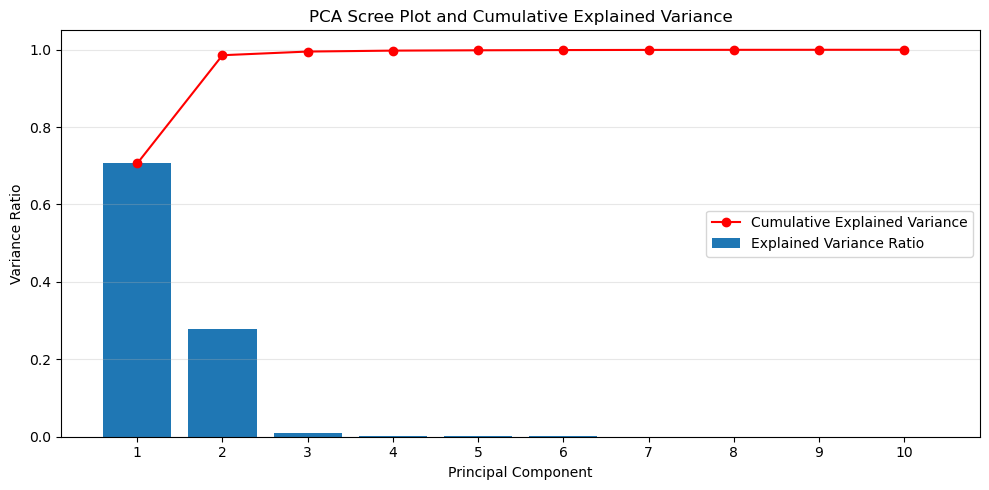

In [21]:
n_show = 10
pcs = np.arange(1, n_show + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pcs, explained_variance_ratio[:n_show], label="Explained Variance Ratio")
ax.plot(pcs, cumulative_variance[:n_show], marker="o", color = "red" ,label="Cumulative Explained Variance")

ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance Ratio")
ax.set_xticks(pcs)
ax.set_ylim(0, 1.05)
ax.set_title("PCA Scree Plot and Cumulative Explained Variance")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="center right")

plt.tight_layout()
plt.show()


PCA Loadings and PCA-Based Wavelength Importance


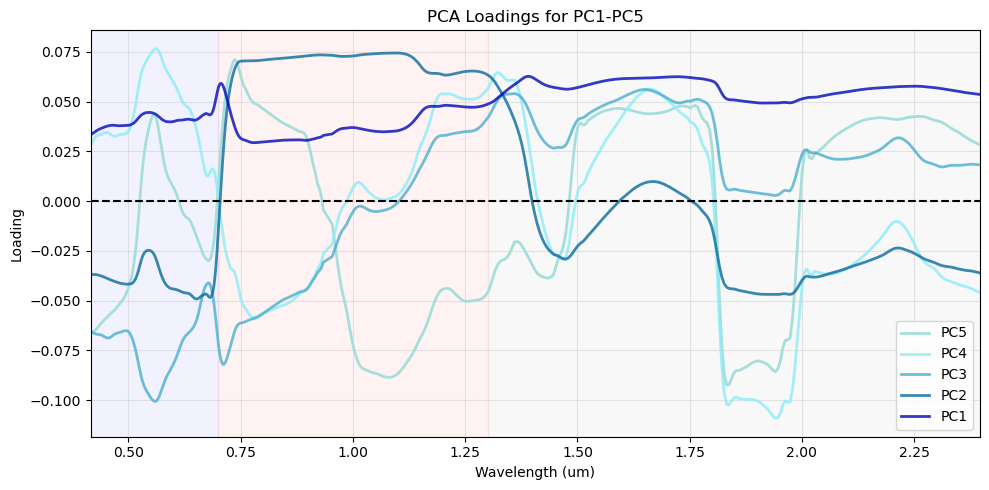

In [10]:
if Vt.shape[1] != len(wavelengths):
    raise ValueError(
        f"Vt has {Vt.shape[1]} bands, but wavelengths has {len(wavelengths)} values."
    )

alphas = [0.80, 0.8, 0.8, 0.8, 1]
blue_shades = ["#0009B8", "#086B9C", "#4AAFCE", "#8CECF9", "#A5DFDC"]

plt.figure(figsize=(10, 5))
for i in reversed(range(5)):
    plt.plot(
        wavelengths,
        Vt[i],
        label=f"PC{i + 1}",
        alpha=alphas[i],
        linewidth=2,
        color=blue_shades[i],
    )

plt.axvspan(0.4, 0.7, color="blue", alpha=0.05)
plt.axvspan(0.7, 1.3, color="red", alpha=0.05)
plt.axvspan(1.3, 2.5, color="gray", alpha=0.05)
plt.axhline(y=0, color="black", linestyle="--")
plt.xlabel("Wavelength (um)")
plt.ylabel("Loading")
plt.title("PCA Loadings for PC1-PC5")
plt.xlim(wavelengths.min(), wavelengths.max())
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


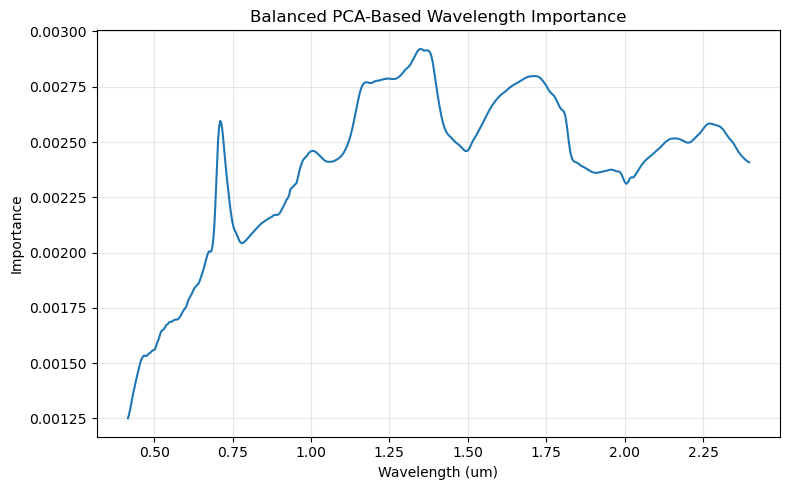

In [11]:
global_pca_importance = np.sum((Vt ** 2) * explained_variance_ratio[:, None], axis=0)
global_pca_importance = global_pca_importance.astype(np.float32)

plt.figure(figsize=(8, 5))
plt.plot(wavelengths, global_pca_importance)
plt.title("Balanced PCA-Based Wavelength Importance")
plt.xlabel("Wavelength (um)")
plt.ylabel("Importance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Verify Stratified PCA

This section applies PCA separately to the sampled pixels from each class. It uses the same balanced mask-based sample created above, so the diagnostic logic matches the paper methodology.


In [12]:
def run_svd_pca_from_standardized_sample(X_region_std):
    region_center_mean = X_region_std.mean(axis=0).astype(np.float32)
    X_region_centered = X_region_std - region_center_mean

    U_region, S_region, Vt_region = np.linalg.svd(X_region_centered, full_matrices=False)

    n_region = X_region_centered.shape[0]
    eigenvalues_region = (S_region ** 2) / (n_region - 1)
    explained_region = eigenvalues_region / eigenvalues_region.sum()
    cumulative_region = np.cumsum(explained_region)

    del U_region

    return (
        S_region.astype(np.float32),
        Vt_region.astype(np.float32),
        region_center_mean,
        explained_region.astype(np.float32),
        cumulative_region.astype(np.float32),
    )

stratified_S = []
stratified_Vt = []
stratified_center_mean = []
stratified_explained = []
stratified_cumulative = []
stratified_mean_reflectance = []

for class_id in class_ids:
    class_name = class_names[int(class_id)]
    print(f"--- {class_name.upper()} ---")

    mask = y_pca == class_id
    X_region = X[mask]
    X_region_std = X_std[mask]

    S_region, Vt_region, center_mean_region, explained_region, cumulative_region = (
        run_svd_pca_from_standardized_sample(X_region_std)
    )

    stratified_S.append(S_region)
    stratified_Vt.append(Vt_region)
    stratified_center_mean.append(center_mean_region)
    stratified_explained.append(explained_region)
    stratified_cumulative.append(cumulative_region)
    stratified_mean_reflectance.append(X_region.mean(axis=0).astype(np.float32))

    print("Samples:", X_region.shape[0])
    print("90%:", np.argmax(cumulative_region >= 0.90) + 1)
    print("95%:", np.argmax(cumulative_region >= 0.95) + 1)
    print("99%:", np.argmax(cumulative_region >= 0.99) + 1)

stratified_S = np.stack(stratified_S).astype(np.float32)
stratified_Vt = np.stack(stratified_Vt).astype(np.float32)
stratified_center_mean = np.stack(stratified_center_mean).astype(np.float32)
stratified_explained = np.stack(stratified_explained).astype(np.float32)
stratified_cumulative = np.stack(stratified_cumulative).astype(np.float32)
stratified_mean_reflectance = np.stack(stratified_mean_reflectance).astype(np.float32)

print("Stratified explained shape:", stratified_explained.shape)
print("Stratified Vt shape:", stratified_Vt.shape)


--- WATER ---
Samples: 50000
90%: 2
95%: 3
99%: 5
--- SOIL ---
Samples: 50000
90%: 2
95%: 3
99%: 5
--- CANOPY ---
Samples: 50000
90%: 1
95%: 2
99%: 4
--- GRASS ---
Samples: 50000
90%: 2
95%: 3
99%: 5
Stratified explained shape: (4, 430)
Stratified Vt shape: (4, 430, 430)


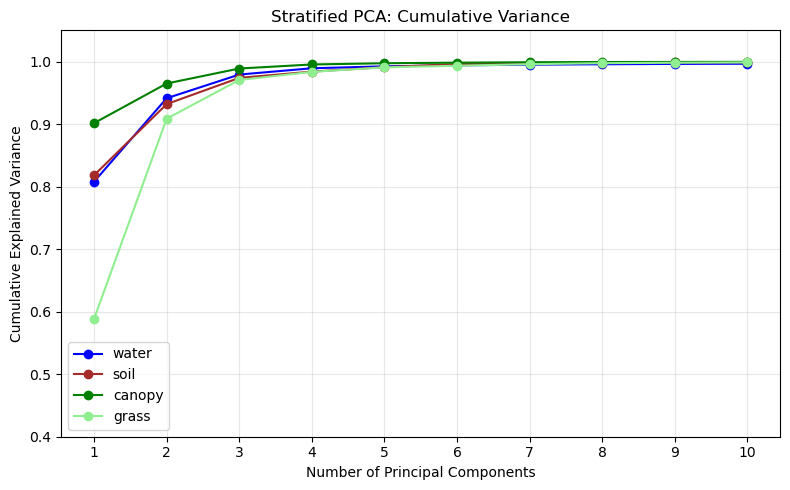

In [13]:
colors = {
    "grass": "lightgreen",
    "water": "blue",
    "canopy": "green",
    "soil": "brown",
}

plt.figure(figsize=(8, 5))
for i, class_id in enumerate(class_ids):
    name = class_names[int(class_id)]
    x = np.arange(1, len(stratified_cumulative[i, :10]) + 1)
    plt.plot(x, stratified_cumulative[i, :10], marker="o", label=name, color=colors[name])

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Stratified PCA: Cumulative Variance")
plt.legend()
plt.xticks(np.arange(1, 11, 1))
plt.ylim(0.4, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


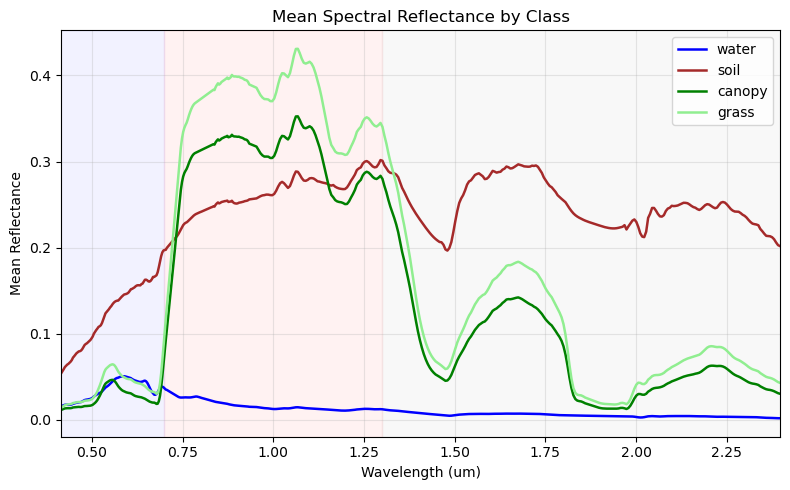

In [15]:
plt.figure(figsize=(8, 5))
for i, class_id in enumerate(class_ids):
    name = class_names[int(class_id)]
    plt.plot(
        wavelengths,
        stratified_mean_reflectance[i],
        label=name,
        color=colors[name],
        linewidth=1.8,
    )

plt.xlabel("Wavelength (um)")
plt.ylabel("Mean Reflectance")
plt.title("Mean Spectral Reflectance by Class")
plt.axvspan(0.4, 0.7, color="blue", alpha=0.05)
plt.axvspan(0.7, 1.3, color="red", alpha=0.05)
plt.axvspan(1.3, 2.5, color="gray", alpha=0.05)
plt.legend()
plt.xlim(wavelengths.min(), wavelengths.max())
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Save Cache Outputs 
This is the only cache output written by the notebook. It contains global preprocessing statistics, balanced sample metadata, PCA outputs, PCA5 features, and stratified PCA diagnostics.


In [16]:
cache_payload = {
    # Metadata
    "rows": np.array(rows, dtype=np.int64),
    "cols": np.array(cols, dtype=np.int64),
    "bands": np.array(bands, dtype=np.int64),
    "chunk_y": np.array(chunk_y, dtype=np.int64),
    "chunk_x": np.array(chunk_x, dtype=np.int64),
    "chunk_b": np.array(chunk_b, dtype=np.int64),
    "wavelengths": wavelengths.astype(np.float32),
    "class_ids": class_ids.astype(np.uint8),
    "class_available_counts": class_available_counts,
    "class_sample_counts": class_sample_counts,

    # Global preprocessing statistics
    "global_mean": global_mean.astype(np.float32),
    "global_std": global_std.astype(np.float32),
    "global_pixel_count": np.array(count, dtype=np.int64),

    # Balanced PCA sample
    "sample_rows": sample_rows.astype(np.int32),
    "sample_cols": sample_cols.astype(np.int32),
    "sample_labels": y_pca.astype(np.uint8),
    "X_labeled_sample_raw": X.astype(np.float32),
    "X_labeled_sample_standardized": X_std.astype(np.float32),

    # Global PCA outputs
    "pca_center_mean": pca_center_mean.astype(np.float32),
    "pca_singular_values": S.astype(np.float32),
    "pca_components_Vt": Vt.astype(np.float32),
    "pca_eigenvalues": eigenvalues.astype(np.float32),
    "pca_explained_variance_ratio": explained_variance_ratio.astype(np.float32),
    "pca_cumulative_variance": cumulative_variance.astype(np.float32),
    "pca_wavelength_importance": global_pca_importance.astype(np.float32),
    "X_pca5": X_pca5.astype(np.float32),

    # Stratified PCA diagnostics
    "stratified_singular_values": stratified_S.astype(np.float32),
    "stratified_components_Vt": stratified_Vt.astype(np.float32),
    "stratified_center_mean": stratified_center_mean.astype(np.float32),
    "stratified_explained_variance_ratio": stratified_explained.astype(np.float32),
    "stratified_cumulative_variance": stratified_cumulative.astype(np.float32),
    "stratified_mean_reflectance": stratified_mean_reflectance.astype(np.float32),
}

np.savez_compressed(GLOBAL_STAT_PATH, **cache_payload)

print("Saved one cache archive:", GLOBAL_STAT_PATH)
print("Number of arrays saved:", len(cache_payload))
print("Archive keys:")
for key in cache_payload.keys():
    print("-", key)


Saved one cache archive: ..\data\cache\global_stats.npz
Number of arrays saved: 32
Archive keys:
- rows
- cols
- bands
- chunk_y
- chunk_x
- chunk_b
- wavelengths
- class_ids
- class_available_counts
- class_sample_counts
- global_mean
- global_std
- global_pixel_count
- sample_rows
- sample_cols
- sample_labels
- X_labeled_sample_raw
- X_labeled_sample_standardized
- pca_center_mean
- pca_singular_values
- pca_components_Vt
- pca_eigenvalues
- pca_explained_variance_ratio
- pca_cumulative_variance
- pca_wavelength_importance
- X_pca5
- stratified_singular_values
- stratified_components_Vt
- stratified_center_mean
- stratified_explained_variance_ratio
- stratified_cumulative_variance
- stratified_mean_reflectance


## Example Loading Cache

Use this cell in later notebooks to load the single cache archive.


In [17]:
# Example load pattern
cache = np.load(GLOBAL_STAT_PATH)

loaded_global_mean = cache["global_mean"]
loaded_global_std = cache["global_std"]
loaded_Vt = cache["pca_components_Vt"]
loaded_X_pca5 = cache["X_pca5"]
loaded_y = cache["sample_labels"]

print("Loaded:", GLOBAL_STAT_PATH)
print("global_mean:", loaded_global_mean.shape)
print("global_std:", loaded_global_std.shape)
print("Vt:", loaded_Vt.shape)
print("X_pca5:", loaded_X_pca5.shape)
print("labels:", loaded_y.shape)


Loaded: ..\data\cache\global_stats.npz
global_mean: (430,)
global_std: (430,)
Vt: (430, 430)
X_pca5: (200000, 5)
labels: (200000,)
